# **Conserved Model B** — $g\,\nabla^2(\phi^2)$ (composite $\nabla$ vertex, d = 1)

A scalar density with a *conserving* (porous-medium-type) nonlinearity, driven by white noise:

$$\partial_t\phi = D\,\partial_x^2\phi - \mu\phi + g\,\partial_x^2(\phi^2) + \eta,\qquad
  \langle\eta\eta\rangle = 2T\,\delta\,\delta.$$

The $\nabla^2$ acts on the $\phi^2$ **composite**, so the vertex carries a momentum-space form
factor on the *response-leg* momentum (`mode='composite'`): $F_R\propto q^2\ell^2$, $F_K\propto q^4$.
The conservation law falls out — the tadpole gets $F=0$ and the bubble $F\propto q^2$, so
$\Sigma(q\to0)\to0$.  This is exactly the case a constant Hartree mass-shift cannot represent.

**Note:** because the dynamics conserve $\int\phi\,dx$, the equal-time variance is *suppressed*
(a weak end-to-end target); the rigorous check is the per-$q$ self-energy (validated to ~1% vs the
independent `loop_dyson` oracle in `tests/test_full_integrator.py`).

In [1]:
import os, sys, time
# --- depth-robust repo root: walk up until we find the 'pipeline' package ---
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))  # so `import daedalus` resolves
os.chdir(os.path.join(_root, 'notebooks'))  # cwd=notebooks/ so relative paths resolve
import numpy as np
import matplotlib.pyplot as plt
import daedalus as dd                                 # shared load → run → plot engine
from models.spatial_field_1d_sim import simulate, equal_time_correlator

def order_label(ell):
    """0->'tree', 1->'tree + 1-loop', 2->'tree + 1-loop + 2-loop'."""
    return ('tree' if ell == 0 else
            'tree + ' + ' + '.join('%d-loop' % j for j in range(1, ell + 1)))

mu, D, g, T = 1.0, 2.0, 0.25, 1.0         # mass, diffusion, conserved coupling, noise temp

# The conserved Model-B theory (g·∇²(φ²) derivative vertex) lives in
# theories/reaction_diffusion_conserved_1d.theory.py — same builder calls,
# action and boundary/initial as the former inline build.  Loaded once here.
model, mod = dd.load_theory('reaction_diffusion_conserved_1d')

## 0. Choose the order — `k` and `ℓ`

In [2]:
# ============================  CHOOSE THE ORDER  ============================
MAX_ELL    = 1      # loop order ℓ:  0 = tree,  1 = +1-loop  (ℓ=2 is correct but slow)
K_EXTERNAL = 2      # correlator order k:  2 = two-point ⟨phiphi⟩
VERBOSE    = True   # True ⇒ print the staged [1/7]…[7/7] pipeline for each order
# ===========================================================================

if K_EXTERNAL != 2:
    raise NotImplementedError("v1 implements the k=2 two-point correlator.")

xs = np.linspace(0.0, 6.0, 25)                       # output separations x ≥ 0
fund = {'mu': mu, 'D': D, 'g': g, 'T': T}            # explicit numeric params (g=0.25)
orders = list(range(0, MAX_ELL + 1))
print('will compute orders ℓ =', orders, ' at k =', K_EXTERNAL)

will compute orders ℓ = [0, 1]  at k = 2


## 1. Theory — every order up to `MAX_ELL` through `compute_cumulants`

The operator-IR action `Lap(phi^2)` lowers to a **composite-derivative vertex**: the pipeline
extracts a per-diagram momentum form factor (`Lap→−k²`) and averages it over the loop momentum by
Gauss–Hermite.  `mode='composite'` is selected automatically from the vertex's base field-degree.

In [3]:
curves = {}
for ell in orders:
    t0 = time.time()
    # dd.run → compute_cumulants with the SAME k / external legs / grid / fund.
    # The theory's d-prefixed fluctuation field is 'dphi'; pass it explicitly so
    # the two external legs match (equivalent to the old [('phi',1),('phi',1)]).
    cfg = dd.Config(k=K_EXTERNAL, max_ell=ell,
                    external_fields=[('dphi', 1), ('dphi', 1)],
                    fundamental=fund, spatial_grid=xs,
                    tau_max=0.0, tau_step=1.0, verbose=VERBOSE)
    out = dd.run(model, cfg, mod)
    mid = out['C_tau_x'].shape[0] // 2               # τ = 0 row
    curves[ell] = np.real(out['C_tau_x'])[mid]
    si = out.get('spatial_info', {}) or {}
    print('%-26s C(0,0) = %.4f   mode = %s   live diagrams = %s   (%.0fs)'
          % (order_label(ell), curves[ell][0], si.get('vertex_mode', '—'),
             si.get('n_live_diagrams', '—'), time.time() - t0))

print('\nvariance C(0,0) by cumulative order:')
for ell in orders:
    print('   %-26s = %.4f' % (order_label(ell), curves[ell][0]))

[1/7] FieldTheory.expand (taylor_order=2)...


[expand-cache] saved order=2 → saved_theories/1d_conserved_reaction_diffusion_derivative_vertex/expand_taylor2.sobj
=== Sanity checks ===
  [PASS]  (n_tilde=0, n_phys=0)  constant term
  [PASS]  (n_tilde=1, n_phys=0)  tadpole — must vanish at MF saddle
  [PASS]  (n_tilde=0, n_phys=1)  linear physical-only — must vanish at EOM
      vtypes: 0, sources: 1 (NoiseSourceType: 0)

      ── MF action (bigrade ≤1 in each index; vanishes at saddle) ──
      bigrade (1, 0):
        phit1  *  (mu*phistar1)

      ── Free action (1,1) bilinear sector ──
        phit1·dphi1  *  (-2*Laplacian*g*phistar1 - D*Laplacian + Dt + mu)

      ── Interaction action (total degree ≥ 2, excluding (1,1)) ──
      bigrade (2,0):
        phit1^2  *  (-T)

      [expand] done in 1.61s
[2/7] Build propagator (K_ker → K_ft → G_ft → D_delta)...

      ── K_mat (shape 1 × 1) ──
        rows (response): ['phit1']
        cols (physical): ['dphi1']
        [0,0] = -2*Laplacian*g*phistar1 - D*Laplacian + Dt + mu

      ──


      ── K_ft (shape 1 × 1) ──
        rows (response): ['phit1']
        cols (physical): ['dphi1']
        [0,0] = -2*Laplacian*g*phistar1 - D*Laplacian + mu + I*omega
      symbolic inverse/adj/det took 0.05s
      ── spatial propagator (d=1, bc=infinite) ──
        G_tx[phit1,dphi1]: A(mass)=mu, B(diff)=2*g*phistar1 + D

      ── D(ω) = det(K_ft) ──
        -2*Laplacian*g*phistar1 - D*Laplacian + mu + I*omega

      ── G_ft = K_ft⁻¹ (shape 1 × 1) ──
        rows (response): ['phit1']
        cols (physical): ['dphi1']
        [0,0] = -1/(2*Laplacian*g*phistar1 + D*Laplacian - mu - I*omega)

      ── adj_ft = G_ft · D(ω) (shape 1 × 1) ──
        rows (response): ['phit1']
        cols (physical): ['dphi1']
        [0,0] = 1

      ── D_delta = lim_{ω→∞} G_ft (instantaneous) (shape 1 × 1) ──
        rows (response): ['phit1']
        cols (physical): ['dphi1']
[propagator] Cached to: saved_theories/1d_conserved_reaction_diffusion_derivative_vertex/propagator.sobj
      [propagator] 

        ell=0: 1 typed diagram(s); 𝒮(Γ)·prefactor(s) = ['2*T']
      certify Phase J (compute_correction_td) at q=[0.0, 0.7, 1.5] → tree modes vs diagram C(q,τ)...


      certify: max rel = 1.99e-16 (tol 1e-08) -> PASS
[6/7] (spatial) Tree level — no loop diagrams to enumerate.
[7/7] (spatial) Analytic q→x FT: Σ_modes free_two_point(mu,D,kap; x,τ) on 1 τ × 25 x points...
[spatial] done — C(x,τ) ready; tree-mode certified=True (max rel 2.0e-16)
tree                       C(0,0) = 0.3536   mode = —   live diagrams = —   (3s)
[1/7] FieldTheory.expand (taylor_order=4)...


[expand-cache] saved order=4 → saved_theories/1d_conserved_reaction_diffusion_derivative_vertex/expand_taylor4.sobj
=== Sanity checks ===
  [PASS]  (n_tilde=0, n_phys=0)  constant term
  [PASS]  (n_tilde=1, n_phys=0)  tadpole — must vanish at MF saddle
  [PASS]  (n_tilde=0, n_phys=1)  linear physical-only — must vanish at EOM
      vtypes: 1, sources: 1 (NoiseSourceType: 0)

      ── MF action (bigrade ≤1 in each index; vanishes at saddle) ──
      bigrade (1, 0):
        phit1  *  (mu*phistar1)

      ── Free action (1,1) bilinear sector ──
        phit1·dphi1  *  (-2*Laplacian*g*phistar1 - D*Laplacian + Dt + mu)

      ── Interaction action (total degree ≥ 2, excluding (1,1)) ──
      bigrade (1,2):
        phit1·dphi1^2  *  (-g)
      bigrade (2,0):
        phit1^2  *  (-T)

      [expand] done in 0.52s
[2/7] Build propagator (K_ker → K_ft → G_ft → D_delta)...
[propagator] Loaded from cache: saved_theories/1d_conserved_reaction_diffusion_derivative_vertex/propagator.sobj

      ── K

      certify: max rel = 1.99e-16 (tol 1e-08) -> PASS
[6/7] (spatial) Enumerate prediagrams + typed diagrams → classify coefficient factors → map to C-stack descriptors (max_ell=1)...
        ell=0: 1 typed diagram(s); 𝒮(Γ)·prefactor(s) = ['2*T']
        ell=1: 3 typed diagram(s); 𝒮(Γ)·prefactor(s) = ['16*T^2*g^2', '8*T^2*g^2', '8*T^2*g^2']


        3 typed diagram(s) → 3 live at the saddle (0 zero-prefactor dropped)
[7/7] (spatial) Full-diagram integration: Σ_Γ 2^(-n_C)·𝒮(Γ) ∫dᵈℓ(Symanzik) ∫dt(causal chambers) → ret+adv → q→x FT [3 live diagram(s), q-grid n_q=64, (mu,D,kap)=(1.0000,2.0000,1.0000)]...
        analytic heat-kernel IFT (plain + d=1 derivative vertices) — no q-grid / no FT (exact)


[spatial] done — C(x,τ) ready; tree-mode certified=True (max rel 2.0e-16)
tree + 1-loop              C(0,0) = 0.3562   mode = composite   live diagrams = 3   (2s)

variance C(0,0) by cumulative order:
   tree                       = 0.3536
   tree + 1-loop              = 0.3562


## 2. Simulation of the SPDE

The conserved nonlinearity enters the spectral integrator as `+g·(−k²)·rfft(φ²)` (the `g_lap`
forcing).  The connected equal-time correlator is averaged over snapshots after burn-in.

In [4]:
snaps, x_grid, meta = simulate(L=20.0, N=200, mu=mu, D=D, T=T, g_lap=g,
                               dt=0.02, n_steps=110000, burn_in=14000,
                               record_every=10, seed=1)
if not np.all(np.isfinite(snaps)) or np.max(np.abs(snaps)) > 30:
    print('WARNING: the simulation blew up (gradient/conserved stiffness) — '
          'reduce the coupling, raise N, or shrink dt.')
mean = float(np.mean(snaps))                         # ⟨φ⟩ (excess velocity for KPZ; ~0 otherwise)
Cx_full = equal_time_correlator(snaps) - mean**2     # CONNECTED correlator (subtract ⟨φ⟩²)
half = len(x_grid) // 2 + 1
xc, Cx = x_grid[:half], Cx_full[:half]               # one period side, x ≥ 0
print('sim ⟨φ⟩ = %.4f   sim connected C(0,0) = %.4f' % (mean, Cx[0]))
print('theory C(0,0) by cumulative order:')
for ell in orders:
    print('   %-26s = %.4f' % (order_label(ell), curves[ell][0]))

sim ⟨φ⟩ = -0.0010   sim connected C(0,0) = 0.3546
theory C(0,0) by cumulative order:
   tree                       = 0.3536
   tree + 1-loop              = 0.3562


## 3. Compare — theory orders vs simulation

The loop correction to the conserved variance is small (conservation suppression); the structural
signature is the momentum-dependent self-energy, not the scalar $C(0,0)$.

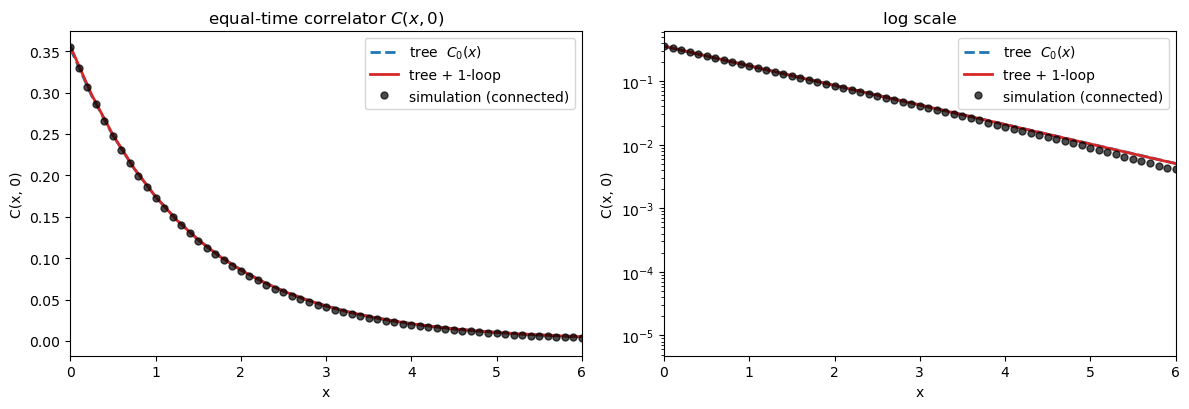

distance |sim − theory| at x=0  (sim connected variance = 0.3546):
   tree                       : |Δ| = 0.0010
   tree + 1-loop              : |Δ| = 0.0017


In [5]:
styles = {0: ('--', 'C0', r'tree  $C_0(x)$'),
          1: ('-',  'C3', 'tree + 1-loop'),
          2: ('-',  'C2', 'tree + 2-loop')}

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for a in ax:
    for ell in orders:
        ls, col, lab = styles[ell]
        a.plot(xs, curves[ell], ls, lw=2, color=col, label=lab)
    a.plot(xc, Cx, 'o', ms=5, color='k', alpha=0.7, label='simulation (connected)')
    a.set_xlabel('x'); a.set_ylabel('C(x, 0)'); a.set_xlim(0, xs.max())
ax[0].set_title('equal-time correlator $C(x,0)$'); ax[0].legend()
ax[1].set_yscale('log'); ax[1].set_title('log scale'); ax[1].legend()
plt.tight_layout(); plt.show()

sim0 = Cx[0]
print('distance |sim − theory| at x=0  (sim connected variance = %.4f):' % sim0)
for ell in orders:
    print('   %-26s : |Δ| = %.4f' % (order_label(ell), abs(sim0 - curves[ell][0])))

## Summary

Model B is the **composite-derivative** representative: the $\nabla^2$ acts on the $\phi^2$ composite,
depositing a momentum form factor $F\propto q^2$ on the loop (`mode='composite'`).  The conservation
law $\Sigma(q\to0)\to0$ emerges from $F=0$ on the tadpole — no model-specific input.

**Knobs:** `MAX_ELL` (loop order), `g` (the conserved coupling), `mu`, `D`, `T`.  The equal-time
variance is conservation-suppressed; the per-$q$ self-energy is the rigorous validation
(`tests/test_full_integrator.py::test_formfactor_bubble_vs_oracle`).